# **The Replication Package of "Tracing Optimization for Performance Modeling and Regression Detection"**

## This is the analysis notebook that leverages program's trace data in order to:

1.   Preprocess the data (i.e., removing outliers, removing non-insightful features)
2.   Determing performance-sensitive functions based on:
    1. Shannon's Entropy
    2. Coefficient of Variation
    3. Performance Correlation (i.e., removing highly correlated features)
    4. Feature Significance (i.e., features with a significant impact on the model)
3.   Building performance models from the optimized trace data
4.   Evaluate the model's capability in detecting performance regressions







## **Environment Initializations**

In [1]:
%pip install pymongo --quiet
%pip install loess --quiet
%pip install ckwrap --quiet
%pip install catboost --quiet
%pip install cliffs-delta --quiet
%pip install xgboost --quiet
%pip install scikit-learn --quiet
%pip install seaborn --quiet
%pip install matplotlib --quiet
%pip install pandas --quiet
%pip install numpy --quiet
%pip install scipy --quiet
%pip install statsmodels --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import json
import random
import re
import matplotlib.pyplot as plt
from matplotlib import pyplot

from collections import defaultdict
import math
import scipy.stats
from scipy.stats import zscore, mannwhitneyu, shapiro, kstest
from itertools import islice
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import cut_tree

from cliffs_delta import cliffs_delta

from ckwrap import ckmeans
from loess.loess_1d import loess_1d

import xgboost as xgb
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, silhouette_score
from scipy.stats import zscore
from sklearn.utils import shuffle

from catboost import CatBoostRegressor

import seaborn as sns

import statsmodels.api as sm
import pymongo

pd.options.display.max_columns = None

In [3]:
class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

## **Determining performance-sensitive functions sets**

In [4]:
# Rounding a value into the closest base (e.g., for binning)
def custom_round(x, base=5, return_int=False):
    if base == 0:
        return x
    if return_int == True:
        return int(base * round(float(x)/base))
    else:
        return base * round(float(x)/base)

**Calculating the Shannon's Entropy**
We first remove the top 2.5% of the data in order to remove the outliers that have a high impact on the entropy values, and then, we calculate the Shannon's entropy for the preprocessed data.

In [5]:
def calculate_entropy(df):
    ent = {}
    for column in df.columns:
        numbers = df[column].to_list()
        percentile = np.percentile(numbers, 97.5)
        numbers = [i for i in numbers if i <= percentile]

        value,counts = np.unique(numbers, return_counts=True)

        entropy = scipy.stats.entropy(counts, base=None)

        if entropy > 0:
            ent[column] = entropy
    return dict(sorted(ent.items(), key=lambda item: item[1], reverse=True))

**Calculating the Coefficient of Variation**
We first remove the top 2.5% of the data in order to remove the outliers that have a high impact on the CV values, and then, we calculate the CV for the preprocessed data.

In [6]:
def calculate_cv(df):
    cvs = {}
    for column in df.columns:
        numbers = df[column].to_list()
        percentile = np.percentile(numbers, 97.5)
        numbers = [i for i in numbers if i <= percentile]

        cv = np.std(numbers, ddof=1) / (np.mean(numbers) + 0.00001)
        if np.isnan(cv):
            cv = 0.0

        if cv > 0:
            cvs[column] = cv

    return dict(sorted(cvs.items(), key=lambda item: item[1], reverse=True))

In [7]:
# Scaling a list into new boundaries (e.g., from x to y)
def scale_number(unscaled, to_min, to_max, from_min, from_max):
    return (to_max-to_min)*(unscaled-from_min)/(from_max-from_min)+to_min

def scale_list(l, to_min, to_max):
    return [scale_number(i, to_min, to_max, min(l), max(l)) for i in l]

In [8]:
def show_corr_heatmap(df, columns):
    sns.set(rc={'figure.figsize':(50, 75)})

    corr = df[columns].corr()
    matrix = np.triu(corr)
    heatmap_plot = sns.heatmap(corr, cmap='RdBu', vmin=-1, vmax=1, annot=True,
                annot_kws={'fontsize':11, 'fontweight':'bold'},
                square=True, mask = matrix, cbar=False)
    heatmap_fig = heatmap_plot.get_figure()

In [9]:
# Calculating various types of errors with the model's predictions and the true values
def get_errors(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mre = np.mean(np.abs(y_true - y_pred) / np.abs(y_true))
    r2 = r2_score(y_true, y_pred)

    mae = math.floor(mae * 1000)/1000.0
    mape = math.floor(mape * 1000)/1000.0
    mse = math.floor(mse * 1000)/1000.0
    rmse = math.floor(rmse * 1000)/1000.0
    mre = math.floor(mre * 1000)/1000.0

    return {'MAE': mae, 'MAPE': mape, 'MSE': mse, 'RMSE': rmse, 'MRE': mre, 'R2': r2}

**Training the performance model.**
This function has two types for training the performance model:
1.   Only train the model without applying K-fold cross-validation.
2.   Evaluating the model's accuracy with a 10-fold cross validation.

In [10]:
def get_model(df, features, model, frac = 1, train_only = False):
    X = df[features]
    y = df['model_output']

    if train_only == True:
        model.fit(X, y)
        return model, None


    k = 10
    kf = KFold(n_splits=k, random_state=None)

    errors = {}
    for train_index, test_index in kf.split(X):
        X_train_kf, X_test_kf = X.iloc[train_index, :], X.iloc[test_index, :]
        y_train_kf, y_test_kf = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train_kf, y_train_kf)

        y_pred_kf = model.predict(X_test_kf)

        errs = get_errors(y_test_kf, y_pred_kf)

        for e_name, e_value in errs.items():
            if e_name not in errors:
                errors[e_name] = []
            errors[e_name].append(e_value)

    # Calculate the average of the errors:
    for e_name, e_values in errors.items():
        average = np.mean(e_values)
        errors[e_name] = average

    return model, errors

In [11]:
def get_turning_points(input):
    points = []

    last_value = input[0]
    for i in range(1, len(input)):
        if input[i] != last_value:
            points.append(i)
            last_value = input[i]

    return points

In [12]:
def cluster_functions(input):
    clusters = {}
    for i in range(0, len(input)):
        if clusters.get(str(input[i]), 0) == 0:
            clusters[str(input[i])] = []
        clusters[str(input[i])].append(i)
    return clusters

**Clustering the functions into performance-sensitive and performance-insensitive groups.**
We first smooth the values of the data using loess function. Then, we calculate the first derivative of the smoothed data, and accordingly, we cluster the results into two groups.

In [13]:
def get_smooth_dxdy_clusters(input, number_of_clusters = 2):
    xout, yout, wout = loess_1d(np.arange(len(list(input.keys()))), np.array(list(input.values())))
    dydx = np.gradient(yout,xout)
    clusters = ckmeans(dydx, number_of_clusters).labels

    return yout, dydx, clusters

In [14]:
# Fetching the trace data from the database
def get_datasets(field='self', target = 'vanilla'):
    programs = ['631_sjeng', '638_imagick', 'su2_cfd', 'parsec_freqmine']
    modes = ['analysis', 'optimized', 'regression']

    datasets = defaultdict(lambda: defaultdict(lambda: defaultdict(defaultdict)))
    for program in programs:
        for mode in modes:
            with open(f'./trace-data/{program}_{mode}.json') as f:
                documents = json.load(f)
            
            if mode == 'analysis':
                data = []
                for doc in documents:
                    if target == 'cpu':
                        if type(doc['stats']['cpu_utilization']) == float:
                            utilization = doc['stats']['cpu_utilization']
                        else:
                            utilization = np.mean(doc['stats']['cpu_utilization'][:8])
                        item = {'model_output': utilization}
                    else:
                        item = {'model_output': doc['times'][target]}

                    for func_name, func_values in doc['functions'].items():
                        func_n = func_name.split('(')[0]
                        if '.' in func_n:
                            continue

                        item[func_n] = func_values[field]

                        if field != 'calls':
                            item[func_n + '_calls'] = func_values['calls']
                    data.append(item)
                if len(data) > 0:
                    datasets[program][mode] = pd.DataFrame(data).fillna(0.0)
            else:
                r_items = defaultdict(defaultdict)
                for doc in documents:
                    if '_old' in doc['build']['type'] or doc['build']['type'] == 'io':
                        continue

                    if target == 'cpu':
                        if program == '638_imagick':
                            utilization = np.mean(doc['stats']['cpu_utilization'][:8])
                        else:
                            utilization = np.mean(doc['stats']['cpu_utilization'][4:6])
                        item = {'model_output': utilization}
                    else:
                        item = {'model_output': doc['times'][target]}

                    item['input_parameters'] = str(doc['parameters'])

                    for func_name, func_values in doc['functions'].items():
                        func_n = func_name.split('(')[0].replace('<', '_')
                        item[func_n] = func_values[field]

                    n_mode = f"{mode}_{doc['build']['type']}_{doc['build']['range']}"

                    if r_items.get(n_mode, -1) == -1:
                        r_items[n_mode] = []
                    r_items[n_mode].append(item)

                for k, v in r_items.items():
                    datasets[program][k] = pd.DataFrame(v).fillna(0.0)

    return datasets

In [15]:
# Fetch the trace data, and put "functions' self execution time" as the features
datasets = get_datasets(field='self')

In [16]:
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode == 'analysis':
            """
            Removing uninformative functions. Since the final performance models uses "functions' call frequency" as the explanatory variables, we remove the
            functions that their unique call frequency is less than one percent of the lenght of the dataset (i.e., 25).
            In other words, we want to remove the functions that their unique call freqiencies is stable through the program's execution. For instance, if a function only executes
            3 times for all of the program's exeuctions (i.e., 2500 executions in this study), we remove it from the dataset since it won't provide insightful information for the performance model.
            """
            uninformative_columns = [col for col in dataset[dataset.columns[dataset.columns != 'model_output']].columns if (not col.endswith('_calls') and len(dataset[col + '_calls'].value_counts()) < 25)]
            datasets[program][mode] = datasets[program][mode].drop(columns=uninformative_columns)

            # We are removign the duplicated features (i.e., the call frequencies) since we want to calculate the Shannon's Entropy and CV based on the functions' execution time
            repetitive_columns = [col for col in datasets[program][mode].columns if col.endswith('_calls')]
            datasets[program][mode] = datasets[program][mode].drop(columns=repetitive_columns)

        try:
            if program == '631_sjeng':
                datasets[program][mode] = datasets[program][mode].drop('int const& std::min<int>', axis=1)
        except Exception as e:
            continue

In [17]:
# Normalizing the datasets
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue
        x_scaled = preprocessing.MaxAbsScaler().fit_transform(dataset[dataset.columns[dataset.columns != 'model_output']].values)
        new_df = pd.DataFrame(x_scaled, columns = dataset[dataset.columns[dataset.columns != 'model_output']].columns)
        new_df.insert(0, 'model_output', dataset['model_output'].values.astype('float'))
        datasets[program][mode] = new_df

In [18]:
# Finding a common bin size for each dataset, and apply it to its columns
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue
        bins = []
        for column in dataset.columns[1:]:
            values = dataset[column].values
            bins.append(3.5 * np.std(values) / np.cbrt(len(values)))
        bin_size = np.median(bins)

        for column in dataset.columns:
            if column == 'model_output':
                continue
            else:
                datasets[program][mode][column] = dataset[column].apply(lambda x: custom_round(x, base=bin_size))

In [19]:
# Calculate Shannon's Entropy and CV
entropies = defaultdict(defaultdict)
cvs = defaultdict(defaultdict)
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue

        entropies[program][mode] = calculate_entropy(dataset.iloc[:,1:])
        cvs[program][mode] = calculate_cv(dataset.iloc[:,1:])

In [20]:
# Split the functions into two groups (performance-sensitive and insensitive)
significant_functions = defaultdict(lambda: defaultdict(defaultdict))
graphs = defaultdict(lambda: defaultdict(lambda: defaultdict(defaultdict)))
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue

        for metric_name, metric in {'entropy': entropies, 'cv': cvs}.items():
            smooth, dydx, clusters = get_smooth_dxdy_clusters(metric[program][mode], 2)

            # Graphs will be used to visualize the clustering
            graphs[program][mode][metric_name]['smooth'] = smooth
            graphs[program][mode][metric_name]['dydx'] = dydx
            graphs[program][mode][metric_name]['split'] = []

            cc = cluster_functions(clusters)
            for key,value in cc.items():
                graphs[program][mode][metric_name]['split'].append(value[0])

                threshold = value[0]

                significant_functions[program][metric_name] = [function.split('(')[0] for function, weight in metric[program][mode].items() if weight >= list(metric[program][mode].values())[threshold]]

        # This is only for further usage. We all of the functions as "correlation" to apply the correlation removal.
        significant_functions[program]['correlation'] = [column for column in dataset.columns if column != 'model_output']

631_sjeng


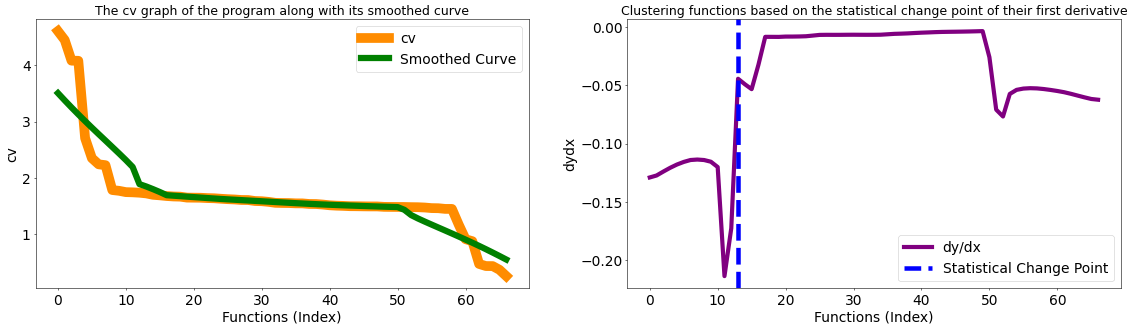

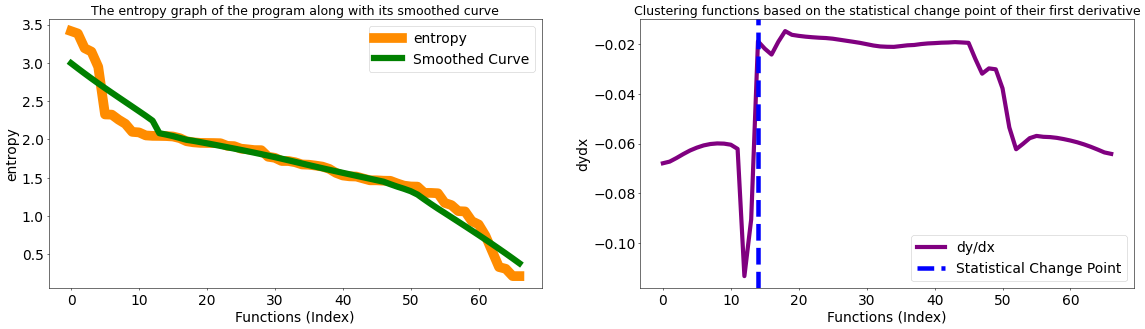

-----------------------------------------------------------------------------------------
638_imagick


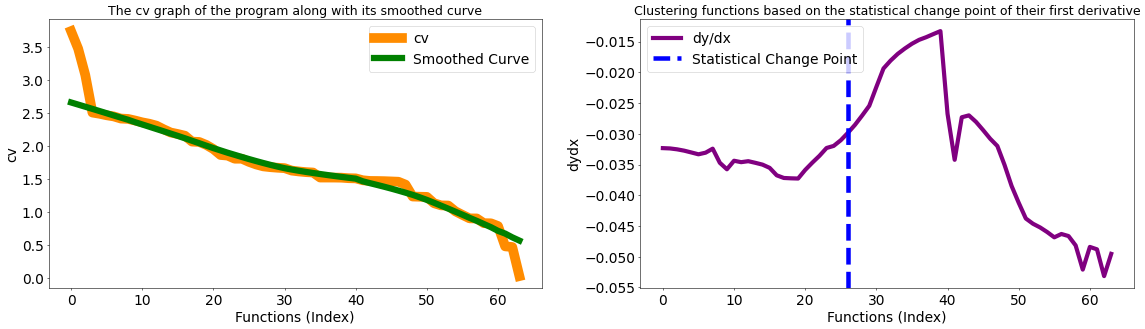

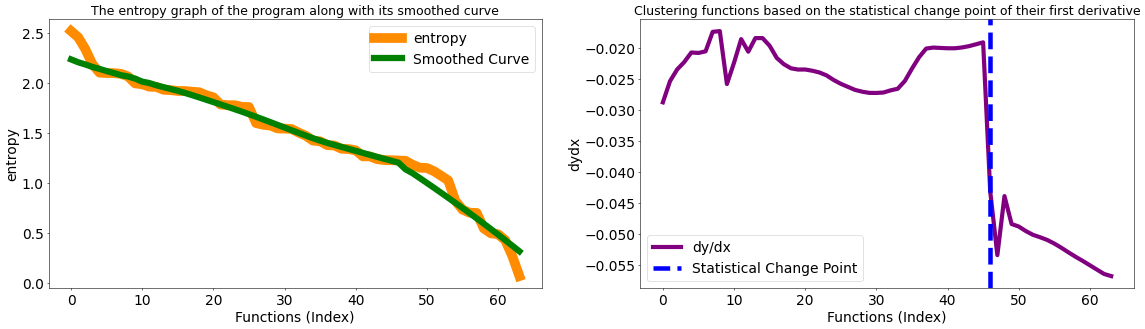

-----------------------------------------------------------------------------------------
su2_cfd


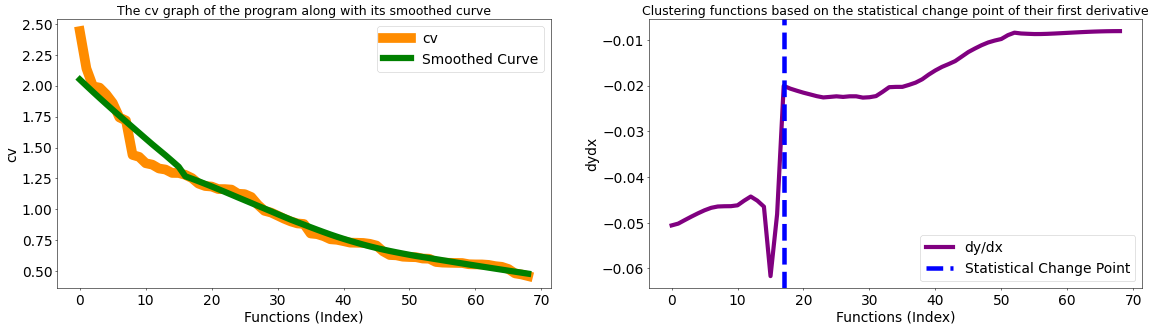

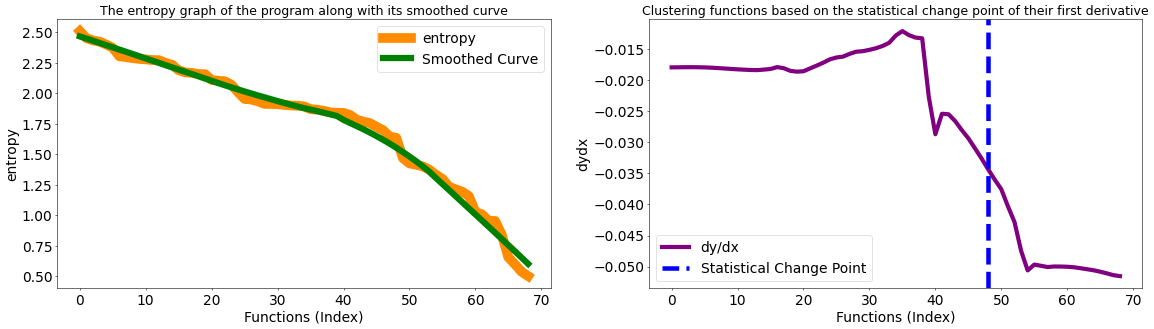

-----------------------------------------------------------------------------------------
parsec_freqmine


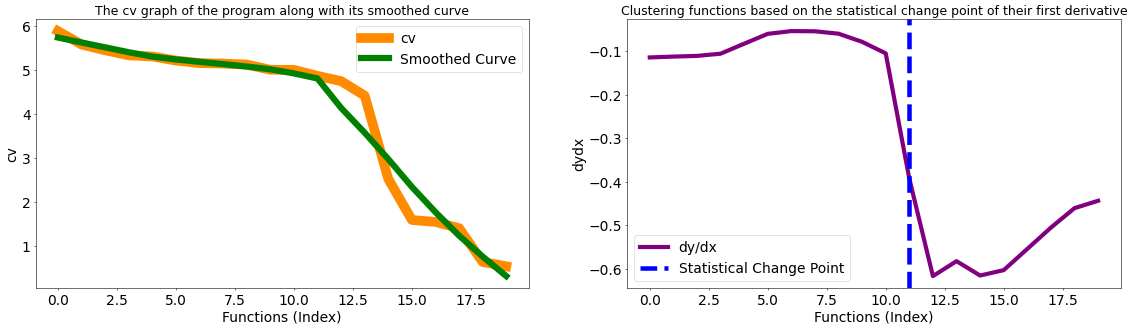

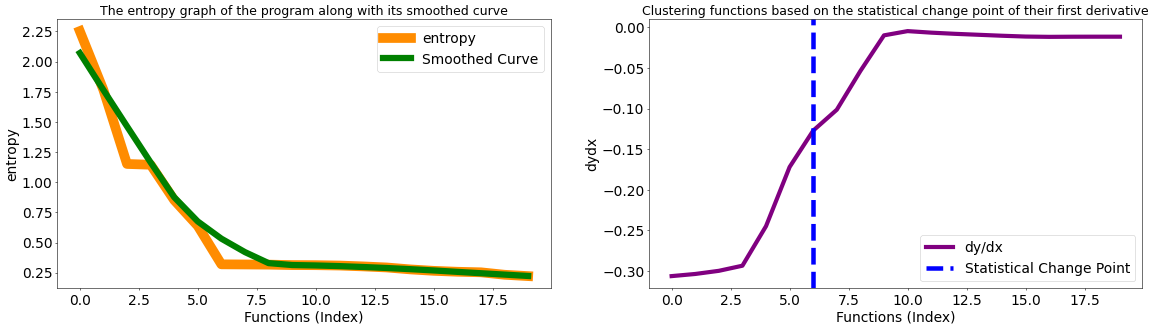

-----------------------------------------------------------------------------------------


In [21]:
plt.rcParams.update({'font.size': 20})

for program, modes in datasets.items():
    print(f"{bcolors.BOLD}{program}{bcolors.ENDC}")
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue

        for metric_name, metric in {'cv': cvs, 'entropy': entropies}.items():
            fig, axes = plt.subplots(1, 2, figsize=(28, 7), dpi=50)

            for i, ax in enumerate(axes):
                if i == 0:
                    ax.plot(list(metric[program][mode].values()), color='darkorange', label=metric_name, linewidth=14)
                    ax.plot(graphs[program][mode][metric_name]['smooth'], color='green', label='Smoothed Curve', linewidth=9)

                    ax.set_ylabel(metric_name)
                    ax.set_title(f"The {metric_name} graph of the program along with its smoothed curve", fontsize=18)
                elif i == 1:
                    ax.plot(list(graphs[program][mode][metric_name]['dydx']), color='purple', label='dy/dx', linewidth=6)
                    for l in graphs[program][mode][metric_name]['split']:
                        if l == 0:
                            continue
                        ax.axvline(x=l, color='blue', linestyle='--', label='Statistical Change Point', linewidth=6.5)

                    ax.set_ylabel("dydx")
                    ax.set_title("Clustering functions based on the statistical change point of their first derivative", fontsize=18)

                ax.set_xlabel("Functions (Index)")
                ax.legend()

            plt.show()
            # plt.savefig('graph.cv.pdf', pad_inches=0.05, bbox_inches='tight')
    print('-----------------------------------------------------------------------------------------')


In [22]:
# Again, fetch the trace datasets with the "functions' call frequencies" as the features
datasets = get_datasets(field='calls')

In [23]:
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue
        try:
            if program == '631_sjeng':
                datasets[program][mode] = datasets[program][mode].drop('int const& std::min<int>', axis=1)

            # Again, remove the functions with "unique call frequencies" less than 1% of the entire dataset (i.e., 25)
            uninformative_columns = [col for col in dataset[dataset.columns[dataset.columns != 'model_output']].columns if len(dataset[col].value_counts()) < 25]
            datasets[program][mode] = datasets[program][mode].drop(columns=uninformative_columns, axis = 1)
        except Exception as e:
            continue

In [24]:
# Test whether the data is distributed normal or non-normal. If nothig prints, so the data is distributed non-normal
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue

        for column in dataset.columns:
            if column == 'model_output':
                continue

            _, p_value_kstest = kstest(dataset[column], 'norm')
            _, p_value_shapiro = shapiro(dataset[column])

            if p_value_kstest > 0.05 or p_value_shapiro > 0.05:
                print(f'{column}: Data looks normally distributed (fail to reject H0)')


**Calculating the feature significance criterion.**
We build a simple linear regression model with the entire analysis dataset, and determine the features that have a significance impact on the model's performance. We use p-value < 0.05 as the threshold.

In [25]:
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue

        ndf = dataset.copy().sample(frac=1, ignore_index=True)
        X = ndf.iloc[:,1:]
        y = ndf.iloc[:,0]

        X_with_intercept = sm.add_constant(X)
        model = sm.OLS(y, X_with_intercept).fit()
        p_values = model.pvalues

        selected_features = []
        if p_values is not None:
            for i, p_value in enumerate(p_values[1:]):
                if p_value < 0.05:
                    selected_features.append(X.columns[i])

        significant_functions[program]['model_importance'] = selected_features

**Removing highly correlated functions.**
Using hierarchial correlation removal, we remove the highly correlate functions using the 0.7 threshold. We apply this removal to "entropy", "CV", and "correlation" sets.

In [26]:
# Removing highly correlated functions
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue
        for metric in ['entropy', 'cv', 'correlation']:
            ndf = dataset.copy()
            ndf = ndf[significant_functions[program][metric]]

            # We use spearman correlation since the data is distributed non-normal
            correlation_matrix = ndf.corr(method='spearman')
            linkage_matrix = hierarchy.linkage(correlation_matrix, method='average')

            threshold = 0.7

            clusters = hierarchy.fcluster(linkage_matrix, threshold, criterion='distance')

            feature_cluster_map = {}
            for feature, cluster in zip(correlation_matrix.columns, clusters):
                if cluster not in feature_cluster_map:
                    feature_cluster_map[cluster] = []
                feature_cluster_map[cluster].append(feature)

            selected_features = [cluster[0] for cluster in feature_cluster_map.values()]

            significant_functions[program][metric + '_correlation' if metric != 'correlation' else metric] = selected_features

**Finding the union of Entropy and CV sets.**
In order to comibe the characteristics of entropy and CV sets, we calculate their union, and make a new set of candidate functions from them. Accordingly, we will have two new sets:

1.   Entropy(w/o correlation removal) / CV(w/o correlation removal)
2.   Entropy(w/ correlation removal) / CV(w/ correlation removal)



In [27]:
# Calculate the union of the sets (e.g., etropy & CV)
for program in list(datasets.keys()):
    # These are the entropy and CV sets after applying the correlation removal (less number of functinos)
    entropy_corr_set = set(significant_functions[program]['entropy_correlation'])
    cv_corr_set = set(significant_functions[program]['cv_correlation'])

    # These are the original sets of entropy and CV (higher number of functions)
    entropy_set = set(significant_functions[program]['entropy'])
    cv_set = set(significant_functions[program]['cv'])

    sets = {'entropy': entropy_set, 'cv': cv_set, 'entropy_corr': entropy_corr_set, 'cv_corr': cv_corr_set}

    for set1, set2 in [('entropy', 'cv'), ('entropy_corr', 'cv_corr')]:
        union = list(sets[set1] | sets[set2])
        significant_functions[program][f'{set1}_and_{set2}'] = union

**Full tracing.**
This set is just for tracing all of the functions in a program.

In [28]:
for program in list(datasets.keys()):
    significant_functions[program]['full'] = ['.']

In [29]:
print(json.dumps(significant_functions, indent=4))

{
    "631_sjeng": {
        "entropy": [
            "comp_to_san",
            "hash_extract_pv",
            "post_thinking",
            "myprintf",
            "rootmovesearch",
            "rtime",
            "rdifftime",
            "history_pre_cut",
            "history_bad",
            "interrupt",
            "add_capture",
            "static_pawn_eval",
            "drawn_endgames",
            "trapped_eval",
            "psq_eval"
        ],
        "cv": [
            "add_king_castle",
            "check_castle_blocker",
            "ProbeTT",
            "full_pawn_eval",
            "taxicab_dist",
            "taxicab_dist_bit",
            "gen_evasions",
            "passer_eval",
            "gen_check_blocks",
            "attacks_to",
            "file",
            "rank",
            "positional_eval",
            "search"
        ],
        "correlation": [
            "rootmovesearch",
            "search",
            "sum_dist",
            "taxicab_dis

## **Determining the regression injection spots**

In [30]:
datasets = get_datasets(field='calls')

In [31]:
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue
        try:
            """
            Some of the functions of this program has the same name, but different call type (e.g., function_name <type 1> and function_name <type 2>)
            Hence, we merge these functions into single ones (i.e., with respect to function's demangling, we only consider the function name).
            """
            if program == 'parsec_freqmine':
                repetitives = [col for col in datasets[program][mode].columns if ' ' in col or '<' in col]
                fixed = list(set([item.split(' ')[1].split('<')[0] for item in repetitives]))

                new_columns = {}
                for item in fixed:
                    for rep in repetitives:
                        if ' ' + item in rep:
                            if item not in new_columns:
                                new_columns[item] = datasets[program][mode][rep]
                            else:
                                new_columns[item] = new_columns[item] + datasets[program][mode][rep]

                    datasets[program][mode][item] = new_columns[item]

                # Remove this particular function since it was not in the program's source (i.e, it might be an external library call)
                repetitives.append('_GLOBAL__sub_I_ITlen')

                datasets[program][mode] = datasets[program][mode].drop(columns=repetitives)
            if program == '631_sjeng':
                # Remove this particular function since it was not in the program's source (i.e, it might be an external library call)
                datasets[program][mode] = datasets[program][mode].drop('int const& std::min<int>', axis=1)
        except Exception as e:
            print(e)
            continue

**Calculate the median number of calls for each function**

In [32]:
program_calls = {}
regression_targets = defaultdict(lambda: defaultdict(lambda: defaultdict(defaultdict)))
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode != 'analysis':
            continue

        calls = dict(sorted({column: int(np.percentile([c for c in dataset[column].to_list() if c > 0], 50)) for column in dataset.iloc[:,1:].columns}.items(), key=lambda item: item[1], reverse=False))

        for col in dataset.iloc[:,1:].columns:
            if np.min(datasets[program][mode][col].to_list()) < 1:
                if col in calls:
                    calls.pop(col)

        """
        We merge the functions that have the same median number of calls, and keep only one of them. This is because since we want to inject only one type of
        performance regression (i.e., constant delay), it doesn't matter if we insert this regression into a function with 8 median calls or to another function
        with the same median calls (The generated performance regression will be same since both of them execute the same number).
        """
        seen_values = set()
        non_repetitive = {}
        for key, value in calls.items():
            if value not in seen_values:
                non_repetitive[key] = value
                seen_values.add(value)

        analysis_list = non_repetitive

        program_calls[program] = calls

**Cluster the functions into three groups based on their median number of calls.**
Using the first and thirt quartiles, we cluster the functions into low-call, medium-call, and high-call.

In [33]:
def find_next_index(dictionary, target_value, checked_indices):
    for key, value in dictionary.items():
        if value == target_value and key not in checked_indices:
            checked_indices.add(key)
            return key

regression_targets = defaultdict(lambda: defaultdict(list))
for program, calls in program_calls.items():
    call_counts = list(calls.values())

    # Removing the outliers using z-score
    z_scores = np.abs(zscore(call_counts))
    z_score_threshold = 4
    call_counts = [call for i, call in enumerate(call_counts) if z_scores[i] <= z_score_threshold]

    q1 = np.percentile(call_counts, 25)
    q3 = np.percentile(call_counts, 75)

    call_data = {
        "low_calls": [],
        "med_calls": [],
        "high_calls": []
    }

    # Iterate through call_counts and categorize them
    for call_count in call_counts:
        if call_count <= q1:
            call_data["low_calls"].append(call_count)
        elif q1 < call_count <= q3:
            call_data["med_calls"].append(call_count)
        else:
            call_data["high_calls"].append(call_count)

    # Since the number of functions in parsec_freqmine program is so limited, we consider 4 functions in this case (instead of 5)
    if program != 'parsec_freqmine':
        number_of_functions = 5
    else:
        number_of_functions = 4

    if len(call_data["low_calls"]) < number_of_functions:
        num_to_fill = number_of_functions - len(call_data["low_calls"])
        call_data["low_calls"].extend(call_data["med_calls"][:num_to_fill])
        call_data["med_calls"] = call_data["med_calls"][num_to_fill:]

    if len(call_data["high_calls"]) < number_of_functions:
        num_to_fill = number_of_functions - len(call_data["high_calls"])
        call_data["high_calls"].extend(call_data["med_calls"][-num_to_fill:])
        call_data["med_calls"] = call_data["med_calls"][:-num_to_fill]

    random.seed(42)

    call_data = {
        category: random.sample(call_data[category], number_of_functions)
        for category in call_data
    }

    random.seed()

    for category, functions in call_data.items():
        checked_indices = set()
        for i in range(number_of_functions):
            func_name = find_next_index(calls, functions[i], checked_indices)
            func_calls = functions[i]
            regression_targets[program][category].append({'function': func_name, 'calls': func_calls})

print(json.dumps(regression_targets, indent=4))

{
    "631_sjeng": {
        "low_calls": [
            {
                "function": "main",
                "calls": 1
            },
            {
                "function": "run_epd_testsuite",
                "calls": 1
            },
            {
                "function": "think",
                "calls": 1
            },
            {
                "function": "clear_pawn_tt",
                "calls": 1
            },
            {
                "function": "SetupPrecalculatedData",
                "calls": 1
            }
        ],
        "med_calls": [
            {
                "function": "clear_tt",
                "calls": 2
            },
            {
                "function": "init_game",
                "calls": 2
            },
            {
                "function": "gen_captures",
                "calls": 85569
            },
            {
                "function": "initialize_hash",
                "calls": 2
            },
            {
        

## **Performance Modeling**

In [34]:
datasets = get_datasets(field='calls', target='full')

In [35]:
for program, modes in datasets.items():
    for mode, dataset in modes.items():
        if mode == 'analysis':
            continue

        # Sort the datasets based on the input parameters. This is used for comparison of the models (i.e., models are trained with the same data).
        if 'input_parameters' in dataset.columns:
            datasets[program][mode] = datasets[program][mode].sort_values(by=['input_parameters'], ascending=False)
            datasets[program][mode] = datasets[program][mode].drop('input_parameters', axis = 1)

        # Fix the naming of the feature
        regex = re.compile(r"\[|\]|<", re.IGNORECASE)
        datasets[program][mode].columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in datasets[program][mode].columns.values]

        datasets[program][mode] = datasets[program][mode].sample(frac=1, random_state=42)

**Train the performance models for each pruning method and evaluate their average perdiction error.**
For each pruning method (e.g., entropy or CV), we build different performance models (e.g., Linear Regression and Random Forest), and then, evaluate their prediction accuracy.

In [36]:
model_errors = defaultdict(lambda: defaultdict((lambda: defaultdict(defaultdict))))
models = defaultdict(lambda: defaultdict((lambda: defaultdict(defaultdict))))
for model_name, model_file in {'LinearRegression': LinearRegression, 'RandomForestRegressor': RandomForestRegressor, 'CatBoostRegressor': CatBoostRegressor, 'XGBoost': xgb.XGBRegressor}.items():
    for program, modes in datasets.items():
        for mode, dataset in modes.items():
            # Only use the "optimized" datasets
            if mode == 'analysis' or 'regression' in mode:
                continue

            input_dataset = dataset.copy()

            n_mode = ('_'.join(mode.split('_')[1:-1])) if mode != 'analysis' else 'analysis'

            model_features = input_dataset.columns[input_dataset.columns != 'model_output']
            model_features = sorted(model_features)

            # Setting the hyper-parameter. These were previously done through a manual analysis.
            match model_name:
                case 'RandomForestRegressor':
                    m_model = model_file(n_estimators=12, random_state=42)

                case 'LinearRegression':
                    m_model = model_file()

                case 'CatBoostRegressor':
                    m_model = model_file(loss_function='RMSE', iterations=200, learning_rate=0.01, logging_level='Silent')

                case 'XGBoost':
                    m_model = model_file(objective='reg:squarederror',n_estimators=100,learning_rate=0.01,random_state=42)

            model, errors = get_model(input_dataset, model_features, model = m_model, train_only=False)

            for e_name, e_value in errors.items():
                model_errors[program][e_name][mode][model_name] = e_value

            # Now, train the performance model with the first 80% of the data. This model will be used later for performance regression detection.
            split_size = int(len(input_dataset) * 0.8)
            train_dataset = input_dataset.iloc[:split_size]
            trained_model, _ = get_model(input_dataset, model_features, model=m_model, train_only=True)
            models[program][n_mode][model_name] = trained_model

In [37]:
# Print the errors (R2 score)
for program, errors in model_errors.items():
    print(program)
    for error_type, model_err in errors.items():
        if error_type != 'R2':
            continue

        for program_type, errs in model_err.items():
            if 'random' in program_type:
                continue

            print(bcolors.BOLD + '\t' + ' '.join(program_type.split('_')[1:-1]) + ' | ' + str(len(datasets[program][program_type].columns) - 1) + bcolors.ENDC)
            for model_name, error_val in errs.items():
                print('\t\tModel: '+ bcolors.BOLD + model_name + bcolors.ENDC, 'R2:', bcolors.BOLD + str(round(error_val, 3)) + bcolors.ENDC)

631_sjeng
	full | 98
		Model: LinearRegression R2: 0.892
		Model: RandomForestRegressor R2: 0.914
		Model: CatBoostRegressor R2: 0.834
		Model: XGBoost R2: 0.754
	entropy | 15
		Model: LinearRegression R2: 0.993
		Model: RandomForestRegressor R2: 0.944
		Model: CatBoostRegressor R2: 0.836
		Model: XGBoost R2: 0.767
	cv | 14
		Model: LinearRegression R2: 0.965
		Model: RandomForestRegressor R2: 0.928
		Model: CatBoostRegressor R2: 0.886
		Model: XGBoost R2: 0.776
	correlation | 9
		Model: LinearRegression R2: 0.948
		Model: RandomForestRegressor R2: 0.844
		Model: CatBoostRegressor R2: 0.788
		Model: XGBoost R2: 0.727
	model importance | 13
		Model: LinearRegression R2: 0.87
		Model: RandomForestRegressor R2: 0.854
		Model: CatBoostRegressor R2: 0.824
		Model: XGBoost R2: 0.739
	entropy correlation | 2
		Model: LinearRegression R2: 0.343
		Model: RandomForestRegressor R2: 0.056
		Model: CatBoostRegressor R2: 0.379
		Model: XGBoost R2: 0.224
	cv correlation | 2
		Model: LinearRegression 

In [38]:
# Determining the best model and metric for each program (based on the models accuracy. It is not the cost-efficiency ratio!). We only consider R2 metric to compare the models.
best_criterion = defaultdict(lambda: defaultdict(lambda: defaultdict()))
for program, errors in model_errors.items():
    for error_type, model_err in errors.items():
        if error_type != 'R2':
            continue

        for program_type, errs in model_err.items():
            pt = ' '.join(program_type.split('_')[1:-1])

            pt = pt + ' - ' + str(len(datasets[program][program_type].columns))

            for model_name, error_val in errs.items():
                error_val = math.floor(error_val * 10000)/10000.0
                if pt not in best_criterion[program]:
                    best_criterion[program][pt] = -np.inf
                if error_val > best_criterion[program][pt]:
                    best_criterion[program][pt] = error_val
                    best_criterion[program] = dict(sorted(best_criterion[program].items(), key=lambda item: item[1], reverse=True))

In [39]:
# Printing the best criterion and model (This is not the cost-efficiency ratio!)
for program, modes in best_criterion.items():
    print(program)
    for mode, e_value in modes.items():
        index = list(modes.keys()).index(mode)

        if index == 0:
            print(bcolors.BOLD + '\t' + mode + '  |  ' + str(e_value) + bcolors.ENDC)
        else:
            print('\t' + mode + ' | ' + str(e_value))

631_sjeng
	entropy - 16  |  0.993
	cv correlation - 3 | 0.986
	entropy correlation random - 3 | 0.9724
	cv - 15 | 0.9646
	entropy and cv - 30 | 0.9522
	correlation - 10 | 0.948
	full - 99 | 0.9142
	entropy corr and cv corr - 5 | 0.9081
	model importance - 14 | 0.8701
	entropy correlation - 3 | 0.3789
638_imagick
	entropy correlation - 8  |  0.9797
	correlation - 13 | 0.9776
	full - 419 | 0.977
	model importance - 5 | 0.9692
	entropy and cv - 62 | 0.9653
	entropy - 47 | 0.9605
	entropy corr and cv corr - 15 | 0.9441
	model importance random - 4 | 0.7804
	cv - 28 | 0.449
	cv correlation - 8 | 0.419
su2_cfd
	full - 746  |  0.9938
	entropy and cv - 49 | 0.9926
	entropy - 43 | 0.9916
	entropy correlation - 5 | 0.99
	cv - 14 | 0.9895
	correlation - 6 | 0.9773
	entropy corr and cv corr - 7 | 0.931
	cv correlation - 3 | 0.9114
	model importance - 10 | 0.8997
	cv correlation random - 3 | -0.0413
parsec_freqmine
	correlation - 6  |  0.9936
	model importance - 14 | 0.9936
	entropy - 8 | 0.9932
	f

In [40]:
mode_list = ['full', 'entropy', 'entropy_correlation', 'cv', 'cv_correlation', 'entropy_and_cv', 'entropy_corr_and_cv_corr', 'correlation', 'model_importance']
model_names = ['LinearRegression', 'RandomForestRegressor', 'CatBoostRegressor', 'XGBoost']

new_error_list = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict())))
for program in list(datasets.keys()):
    print(f"{bcolors.BOLD}{program}{bcolors.ENDC}")
    for mode in mode_list:
        for error_type in ['MAE', 'RMSE', 'R2']:
            for model_name, model_error in model_errors[program][error_type]['optimized_' + mode + '_itself'].items():
                new_error_list[program][mode][model_name][error_type] = model_error

        for model_name in model_names:
            print(model_name, end=' => ')
            for error_type, error_value in new_error_list[program][mode][model_name].items():
                print(error_type + ' is: ' + str(math.floor(error_value * 100)/100.0), end=', ')
        print()
    print()

631_sjeng
LinearRegression => MAE is: 3.74, RMSE is: 6.76, R2 is: 0.89, RandomForestRegressor => MAE is: 2.75, RMSE is: 6.68, R2 is: 0.91, CatBoostRegressor => MAE is: 4.67, RMSE is: 9.51, R2 is: 0.83, XGBoost => MAE is: 6.54, RMSE is: 11.47, R2 is: 0.75, 
LinearRegression => MAE is: 0.08, RMSE is: 0.2, R2 is: 0.99, RandomForestRegressor => MAE is: 0.18, RMSE is: 0.55, R2 is: 0.94, CatBoostRegressor => MAE is: 0.49, RMSE is: 1.01, R2 is: 0.83, XGBoost => MAE is: 0.68, RMSE is: 1.2, R2 is: 0.76, 
LinearRegression => MAE is: 0.54, RMSE is: 0.89, R2 is: 0.34, RandomForestRegressor => MAE is: 0.56, RMSE is: 1.03, R2 is: 0.05, CatBoostRegressor => MAE is: 0.5, RMSE is: 0.88, R2 is: 0.37, XGBoost => MAE is: 0.56, RMSE is: 0.96, R2 is: 0.22, 
LinearRegression => MAE is: 0.27, RMSE is: 0.65, R2 is: 0.96, RandomForestRegressor => MAE is: 0.37, RMSE is: 0.9, R2 is: 0.92, CatBoostRegressor => MAE is: 0.65, RMSE is: 1.22, R2 is: 0.88, XGBoost => MAE is: 1.09, RMSE is: 1.72, R2 is: 0.77, 
LinearReg

**Evaluating the overhead of different optimization criterion.**
We calculate the overheads of execution time and storage usage for each pruning method (e.g., Entropy or CV).

In [41]:
programs = ['su2_cfd', '638_imagick', '631_sjeng', 'parsec_freqmine']
overheads = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict())))

def get_full_stats(documents, parameters):
    for doc in documents:
        if doc['parameters'] == parameters:
            return doc
    return None

def convert_size(size_bytes):
    units = ['KB', 'MB', 'GB', 'TB']
    i = 0
    while size_bytes >= 1024 and i < len(units) - 1:
        size_bytes /= 1024.0
        i += 1
    return f"{size_bytes:.2f}{units[i]}"

for program in programs:
    print(f"{bcolors.BOLD}{program}{bcolors.ENDC}")

    with open(f'./trace-data/{program}_optimized.json') as f:
        optimized_db = json.load(f)

    with open(f'./trace-data/{program}_vanilla.json') as f:    
        vanilla_db = json.load(f)

    for target in ['times', 'sizes']:
        print('Execution Time Overheads' if target == 'times' else 'Storage Usage Overheads', end=' => ')

        percents = {}
        for item in optimized_db:
            original_item = get_full_stats(vanilla_db, item['parameters'])
            if original_item is None:
                continue

            overhead_metrics = {
                'vanilla': 1 if target == 'sizes' else original_item[target]['vanilla'],
                'optimized': item[target]['full']
            }

            if target == 'times':
                val = ((overhead_metrics['optimized'] - overhead_metrics['vanilla']) / overhead_metrics['vanilla']) * 100
            else:
                val = overhead_metrics['optimized']

            if item['build']['type'] not in percents:
                percents[item['build']['type']] = []
            percents[item['build']['type']].append(val)
        for k,v in percents.items():
            if target == 'times':
                print(k + ' is:',str(round(np.mean(v),2)) + '%', end=', ')
                overheads[program][k]['time'] = np.mean(v)
            else:
                print(k + ' is:', convert_size(np.mean(v)), end=', ')
        print()
    print('--------------------------')

su2_cfd
Execution Time Overheads => full is: 77.11%, entropy is: 34.68%, cv is: 4.59%, correlation is: 12.49%, model_importance is: 3.95%, entropy_correlation is: 12.52%, cv_correlation is: 2.23%, entropy_and_cv is: 35.39%, entropy_corr_and_cv_corr is: 14.28%, cv_correlation_random is: 1.62%, 
Storage Usage Overheads => full is: 748.58MB, entropy is: 487.03MB, cv is: 23.29MB, correlation is: 140.88MB, model_importance is: 21.65MB, entropy_correlation is: 143.46MB, cv_correlation is: 7.45MB, entropy_and_cv is: 501.05MB, entropy_corr_and_cv_corr is: 147.29MB, cv_correlation_random is: 3.65MB, 
--------------------------
638_imagick
Execution Time Overheads => full is: 168.37%, entropy is: 100.35%, cv is: 28.3%, correlation is: 28.29%, model_importance is: 23.08%, entropy_correlation is: 24.97%, cv_correlation is: 14.29%, entropy_and_cv is: 103.13%, entropy_corr_and_cv_corr is: 32.03%, model_importance_random is: 16.66%, 
Storage Usage Overheads => full is: 899.36MB, entropy is: 832.37MB,

**Cost-Efficiency Ratio.**
In here, we calculate the cost-efficiency ratio. This metric indicates the ratio of accuracy change in the optimized performance model compared to the full tracing performance model agains the overhead reduction between the models. It can be described as follow:

$$\textit{Cost-Efficiency Ratio} = \frac{\frac{\textit{Optimized Model's Accuracy ($R^2$)}}{\textit{Vanilla Model's Accuracy ($R^2$)}}}{\frac{\textit{Optimized Model's Overhead (Execution Time)}}{\textit{Vanilla Model's Overhead (Execution Time)}}}$$

The higher ratio indicates less accuracy loss (or higher accuracy improvement) against higher overhead reduction. In contrast, a lower ratio shows less overhead reduction and higher accuracy loss (or less accuracy improvement).


In [42]:
for program in list(datasets.keys()):
    print(f"{bcolors.BOLD}{program}{bcolors.ENDC}")
    for model_name in model_names:
        for mode in mode_list:
            if mode == 'full':
                continue

            print('Mode is ' + mode, end= ': ')

            full_error_val = new_error_list[program]['full'][model_name]['R2']
            optimized_error_val = new_error_list[program][mode][model_name]['R2']

            full_overhead = overheads[program]['full']['time']
            optimized_overhead = overheads[program][mode]['time']

            error_difference = optimized_error_val / full_error_val
            overhead_difference = optimized_overhead / full_overhead

            accuracy_overhead_metric = error_difference / overhead_difference

            print(math.floor(accuracy_overhead_metric * 100)/100.0, end=', ')
        print()
    print()

631_sjeng
Mode is entropy: 16.75, Mode is entropy_correlation: 403.13, Mode is cv: 8.95, Mode is cv_correlation: 105.37, Mode is entropy_and_cv: 5.85, Mode is entropy_corr_and_cv_corr: 66.11, Mode is correlation: 43.72, Mode is model_importance: 4.15, 
Mode is entropy: 15.54, Mode is entropy_correlation: 64.11, Mode is cv: 8.41, Mode is cv_correlation: 99.35, Mode is entropy_and_cv: 5.68, Mode is entropy_corr_and_cv_corr: 56.44, Mode is correlation: 37.98, Mode is model_importance: 3.98, 
Mode is entropy: 15.09, Mode is entropy_correlation: 476.37, Mode is cv: 8.79, Mode is cv_correlation: 97.24, Mode is entropy_and_cv: 5.78, Mode is entropy_corr_and_cv_corr: 60.14, Mode is correlation: 38.88, Mode is model_importance: 4.2, 
Mode is entropy: 15.31, Mode is entropy_correlation: 311.71, Mode is cv: 8.51, Mode is cv_correlation: 98.16, Mode is entropy_and_cv: 5.71, Mode is entropy_corr_and_cv_corr: 62.05, Mode is correlation: 39.64, Mode is model_importance: 4.17, 

638_imagick
Mode is en

## **Regression Detection**

**Evaluate optimized performance models (with and without regression) on the new data (with and without regression).**
We test the difference of the predictions of two optimized performance models on the new data. We determine if the difference between the predictions is significant (i.e., using the p-value < 0.05 from Mann-Whitney U-test) and the effect size of this difference (i.e., small, medium, or large) using Cliff's Effect Delta Size.

Then, we determine the original optimized performance model (w/o regression) is capable to detect how many injected performance regression (i.e., out ot 15 injected regressions)

In [43]:
detections = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

for program, modes in datasets.items():
    print(f"{bcolors.BOLD}{program}{bcolors.ENDC}")
    for mode, dataset in modes.items():
        for model_name, model_file in {'LinearRegression': LinearRegression, 'RandomForestRegressor': RandomForestRegressor, 'CatBoostRegressor': CatBoostRegressor, 'XGBoost': xgb.XGBRegressor}.items():
            if 'regression' not in mode or 'random' in mode:
                continue

            input_dataset = dataset.copy()

            if 'baseline' in mode:
                n_mode = ('_'.join(mode.split('_')[1:-2]))
            else:
                n_mode = ('_'.join(mode.split('_')[1:-3]))

            model_features = input_dataset.columns[input_dataset.columns != 'model_output']
            model_features = sorted(model_features)

            match model_name:
                case 'RandomForestRegressor':
                    m_model = model_file(n_estimators=12, random_state=42)

                case 'LinearRegression':
                    m_model = model_file()

                case 'CatBoostRegressor':
                    m_model = model_file(loss_function='RMSE', iterations=200, learning_rate=0.01, logging_level='Silent')

                case 'XGBoost':
                    m_model = model_file(objective='reg:squarederror',n_estimators=100,learning_rate=0.01,random_state=42)

            split_size = int(len(input_dataset) * 0.8)
            train_dataset = input_dataset.iloc[:split_size]
            test_dataset = input_dataset.iloc[split_size:]

            regression_model, _ = get_model(input_dataset, model_features, model=m_model, train_only=True)

            original_model = models[program][n_mode][model_name]

            X_test = test_dataset[model_features]
            y_true = test_dataset['model_output']
            original_pred = original_model.predict(X_test)
            regression_pred = regression_model.predict(X_test)

            original_ae = np.abs(y_true - original_pred)
            regression_ae = np.abs(y_true - regression_pred)

            _, p_value = mannwhitneyu(original_ae, regression_ae)
            delta, cliff = cliffs_delta(original_ae,regression_ae)

            if 'itself' in mode:
                if p_value < 0.01:
                    p_value_text = '<<0.01'
                elif p_value < 0.05:
                    p_Value_text = '<<0.05'
                else:
                    p_value_text = str(round(p_value, 3))
                print('P-value is:', p_value_text + ' and Effect Size [delta] is: ' + cliff.upper() + '.[' + str(round(delta, 3)) + ']')
            else:
                if p_value > 0.05 or cliff == 'negligible':
                    detections[program][model_name]['negligible'] += 1
                else:
                    detections[program][model_name][cliff] += 1

631_sjeng
P-value is: 0.51 and Effect Size [delta] is: NEGLIGIBLE.[-0.066]
P-value is: <<0.01 and Effect Size [delta] is: MEDIUM.[0.473]
P-value is: <<0.01 and Effect Size [delta] is: MEDIUM.[0.385]
P-value is: <<0.01 and Effect Size [delta] is: LARGE.[0.707]
638_imagick
P-value is: <<0.01 and Effect Size [delta] is: SMALL.[0.263]
P-value is: <<0.01 and Effect Size [delta] is: LARGE.[0.676]
P-value is: 0.104 and Effect Size [delta] is: SMALL.[0.163]
P-value is: 0.709 and Effect Size [delta] is: NEGLIGIBLE.[-0.038]
su2_cfd
P-value is: 0.6 and Effect Size [delta] is: NEGLIGIBLE.[-0.053]
P-value is: 0.6 and Effect Size [delta] is: SMALL.[0.202]
P-value is: 0.8 and Effect Size [delta] is: NEGLIGIBLE.[0.026]
P-value is: 0.735 and Effect Size [delta] is: NEGLIGIBLE.[0.034]
parsec_freqmine
P-value is: <<0.01 and Effect Size [delta] is: LARGE.[0.982]
P-value is: <<0.01 and Effect Size [delta] is: LARGE.[0.747]
P-value is: <<0.01 and Effect Size [delta] is: LARGE.[1.0]
P-value is: <<0.01 and Ef

In [44]:
# The efficiency of the optimized performance models in detecting the performance regressions
print(json.dumps(detections, indent=4))

{
    "631_sjeng": {
        "LinearRegression": {
            "negligible": 2,
            "large": 11,
            "small": 1,
            "medium": 1
        },
        "RandomForestRegressor": {
            "medium": 6,
            "small": 8,
            "negligible": 1
        },
        "CatBoostRegressor": {
            "small": 6,
            "negligible": 2,
            "medium": 6,
            "large": 1
        },
        "XGBoost": {
            "large": 6,
            "negligible": 1,
            "medium": 6,
            "small": 2
        }
    },
    "638_imagick": {
        "LinearRegression": {
            "negligible": 10,
            "large": 3,
            "medium": 2
        },
        "RandomForestRegressor": {
            "large": 14,
            "medium": 1
        },
        "CatBoostRegressor": {
            "negligible": 10,
            "large": 5
        },
        "XGBoost": {
            "negligible": 10,
            "large": 3,
            "medium": 2
  